# Bank Customer Churn & CLV Prediction
### A Machine Learning Project for Customer Retention

---

**Objective:** This notebook builds an end-to-end machine learning pipeline to:
1. **Explore** bank customer data through rich EDA
2. **Predict** customer churn with high accuracy (XGBoost + Logistic Regression)
3. **Estimate** Customer Lifetime Value (CLV) using regression models
4. **Identify** high-priority customers for targeted retention campaigns
5. **Interpret** model decisions using SHAP explainability

---

| Field | Details |
|---|---|
| **Dataset** | 50,000 bank customers |
| **Target (Churn)** | `Exited` — 0 = Retained, 1 = Churned |
| **Target (CLV)** | `CLV` — Continuous monetary value |
| **Models** | Logistic Regression, Random Forest, XGBoost, Ridge Regression |


## 1. Imports & Configuration

In [11]:
# Standard Library 
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation 
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Classification Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Regression Models 
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation 
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# Explainability 
import shap

# Global Plot Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RANDOM_STATE = 42
print(" All libraries loaded successfully!")


 All libraries loaded successfully!


## 2. Load & Inspect Data

In [44]:
# Load the dataset
df = pd.read_csv('../data/bank_customers_large.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head(8)


Dataset shape: 50,000 rows × 16 columns
Memory usage: 16.9 MB


,CustomerID,Age,Gender,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,CreditScore,TotalTransactions,AverageTransactionValue,AccountType,Region,Exited,CLV
0,1,56,Male,3,245992.72,2,No,Yes,129215.11,478,183,2230.48,Premium,West,0,23550.12
1,2,69,Male,1,23364.19,2,No,No,135716.82,519,27,487.71,Standard,North,0,2014.38
2,3,46,Male,8,233653.73,3,No,Yes,166874.29,620,88,4359.91,Premium,East,0,19477.59
3,4,32,Male,12,101036.66,1,No,No,69206.77,666,19,1803.90,Standard,North,0,1493.64
4,5,60,Male,19,24205.86,2,No,Yes,173683.91,515,29,3032.25,Standard,South,1,2460.90
5,6,25,Male,1,94793.33,3,Yes,No,111622.88,603,56,4485.71,Standard,North,0,7949.97
6,7,38,Male,18,187413.59,3,No,Yes,127159.55,645,29,3032.50,Premium,South,0,17784.60
7,8,56,Male,7,106193.22,1,Yes,Yes,89112.20,551,23,3385.14,Standard,South,1,4962.71


In [13]:
# Quick summary of data types, nulls, and basic stats
print("── Column Info ──────────────────────────────────")
print(df.dtypes.to_string())
print(f"\nTotal null values: {df.isnull().sum().sum()}")
print(f"Duplicate rows:    {df.duplicated().sum()}")


── Column Info ──────────────────────────────────
CustomerID                   int64
Age                          int64
Gender                         str
Tenure                       int64
Balance                    float64
NumOfProducts                int64
HasCreditCard                  str
IsActiveMember                 str
EstimatedSalary            float64
CreditScore                  int64
TotalTransactions            int64
AverageTransactionValue    float64
AccountType                    str
Region                         str
Exited                       int64
CLV                        float64

Total null values: 0
Duplicate rows:    0


In [14]:
# Statistical summary for numerical features
df.describe().round(2)


,CustomerID,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,CreditScore,TotalTransactions,AverageTransactionValue,Exited,CLV
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,43.51,9.49,125175.62,2.49,109817.41,574.17,99.54,2513.70,0.25,7491.10
std,14433.90,14.99,5.76,72230.36,1.12,51918.25,158.45,57.87,1439.14,0.43,5512.23
min,1.00,18.00,0.00,6.88,1.00,20000.40,300.00,0.00,10.02,0.00,0.20
25%,12500.75,31.00,4.00,62227.59,2.00,64756.79,437.00,49.00,1266.46,0.00,3053.35
50%,25000.50,43.00,10.00,125463.56,2.00,109803.93,573.00,100.00,2522.35,0.00,6075.45
75%,37500.25,56.00,14.00,187708.47,3.00,154894.44,711.00,150.00,3760.66,0.00,10820.68
max,50000.00,69.00,19.00,249997.35,4.00,199986.89,849.00,199.00,4999.89,1.00,25852.14


## 3. Exploratory Data Analysis (EDA)

We'll examine:
- Target class balance (Churn)
- CLV distribution
- Key feature distributions
- Relationships between features and churn


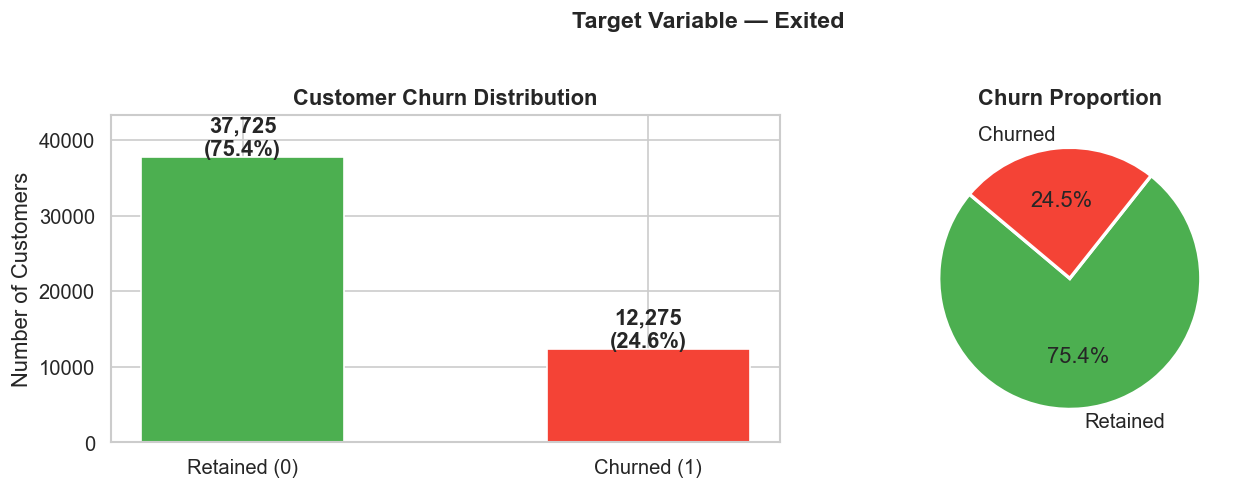

Class imbalance ratio: 1:3 (Churned:Retained)


In [15]:
# 3.1 Churn Distribution 
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
for i, (cnt, pct) in enumerate(zip(churn_counts, churn_pct)):
    axes[0].text(i, cnt + 300, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Customer Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
axes[1].pie(churn_counts, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Target Variable — Exited', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: 1:{churn_counts[0]//churn_counts[1]:.0f} (Churned:Retained)")


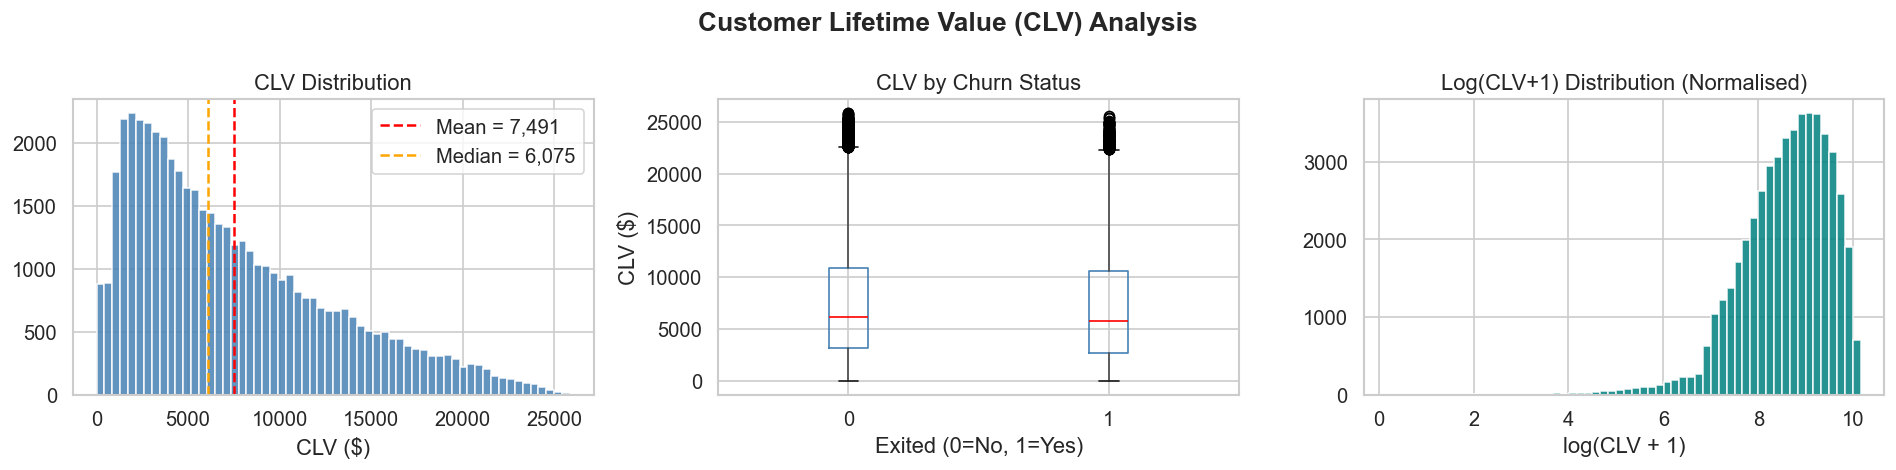

In [16]:
# 3.2 CLV Distribution 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['CLV'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['CLV'].mean(), color='red', linestyle='--', label=f"Mean = {df['CLV'].mean():,.0f}")
axes[0].axvline(df['CLV'].median(), color='orange', linestyle='--', label=f"Median = {df['CLV'].median():,.0f}")
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].legend()

# CLV by Churn
df.boxplot(column='CLV', by='Exited', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('CLV by Churn Status')
axes[1].set_xlabel('Exited (0=No, 1=Yes)')
axes[1].set_ylabel('CLV ($)')
plt.sca(axes[1])
plt.title('CLV by Churn Status')

# Log-transformed CLV
axes[2].hist(np.log1p(df['CLV']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[2].set_title('Log(CLV+1) Distribution (Normalised)')
axes[2].set_xlabel('log(CLV + 1)')

plt.suptitle('Customer Lifetime Value (CLV) Analysis', fontweight='bold')
plt.tight_layout()
plt.show()


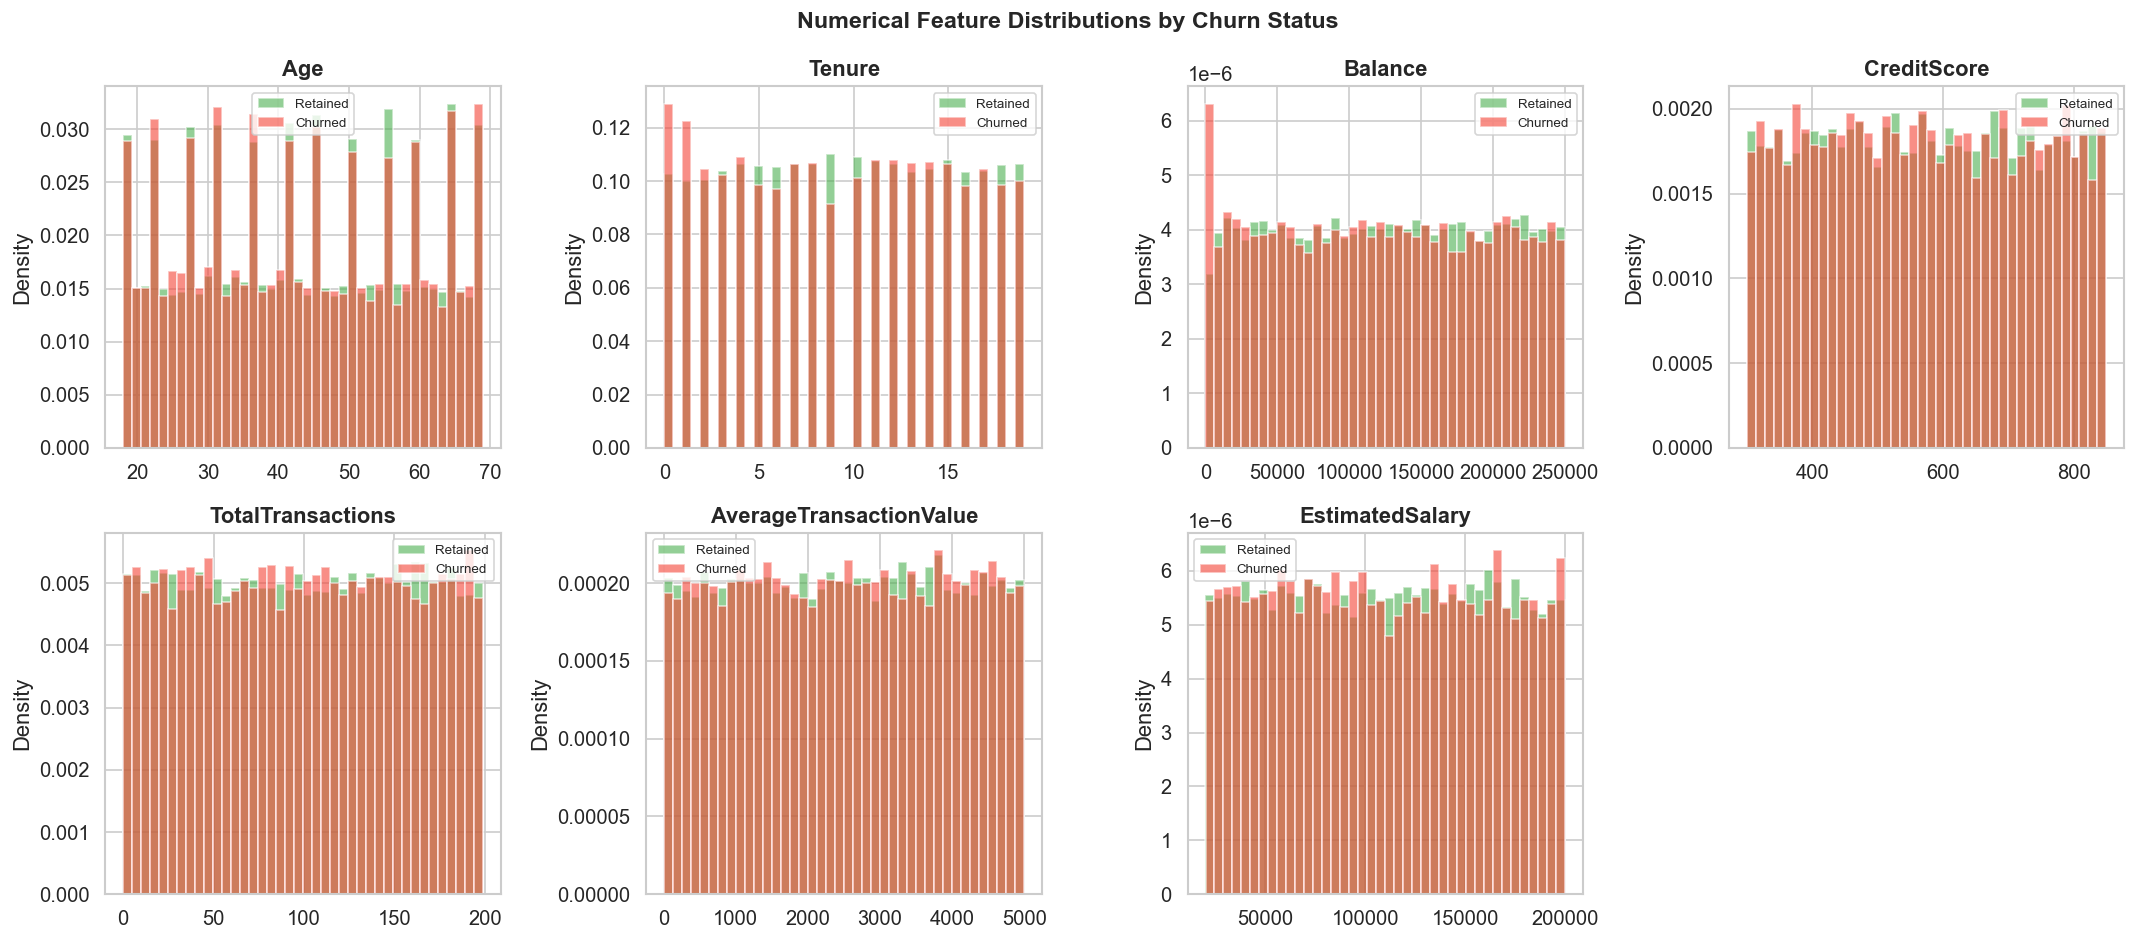

In [17]:
# 3.3 Numerical Feature Distributions by Churn
num_features = ['Age', 'Tenure', 'Balance', 'CreditScore',
                'TotalTransactions', 'AverageTransactionValue', 'EstimatedSalary']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        ax.hist(df[df['Exited'] == label][col], bins=40,
                alpha=0.6, color=color,
                label='Retained' if label == 0 else 'Churned',
                density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # Hide unused subplot
plt.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


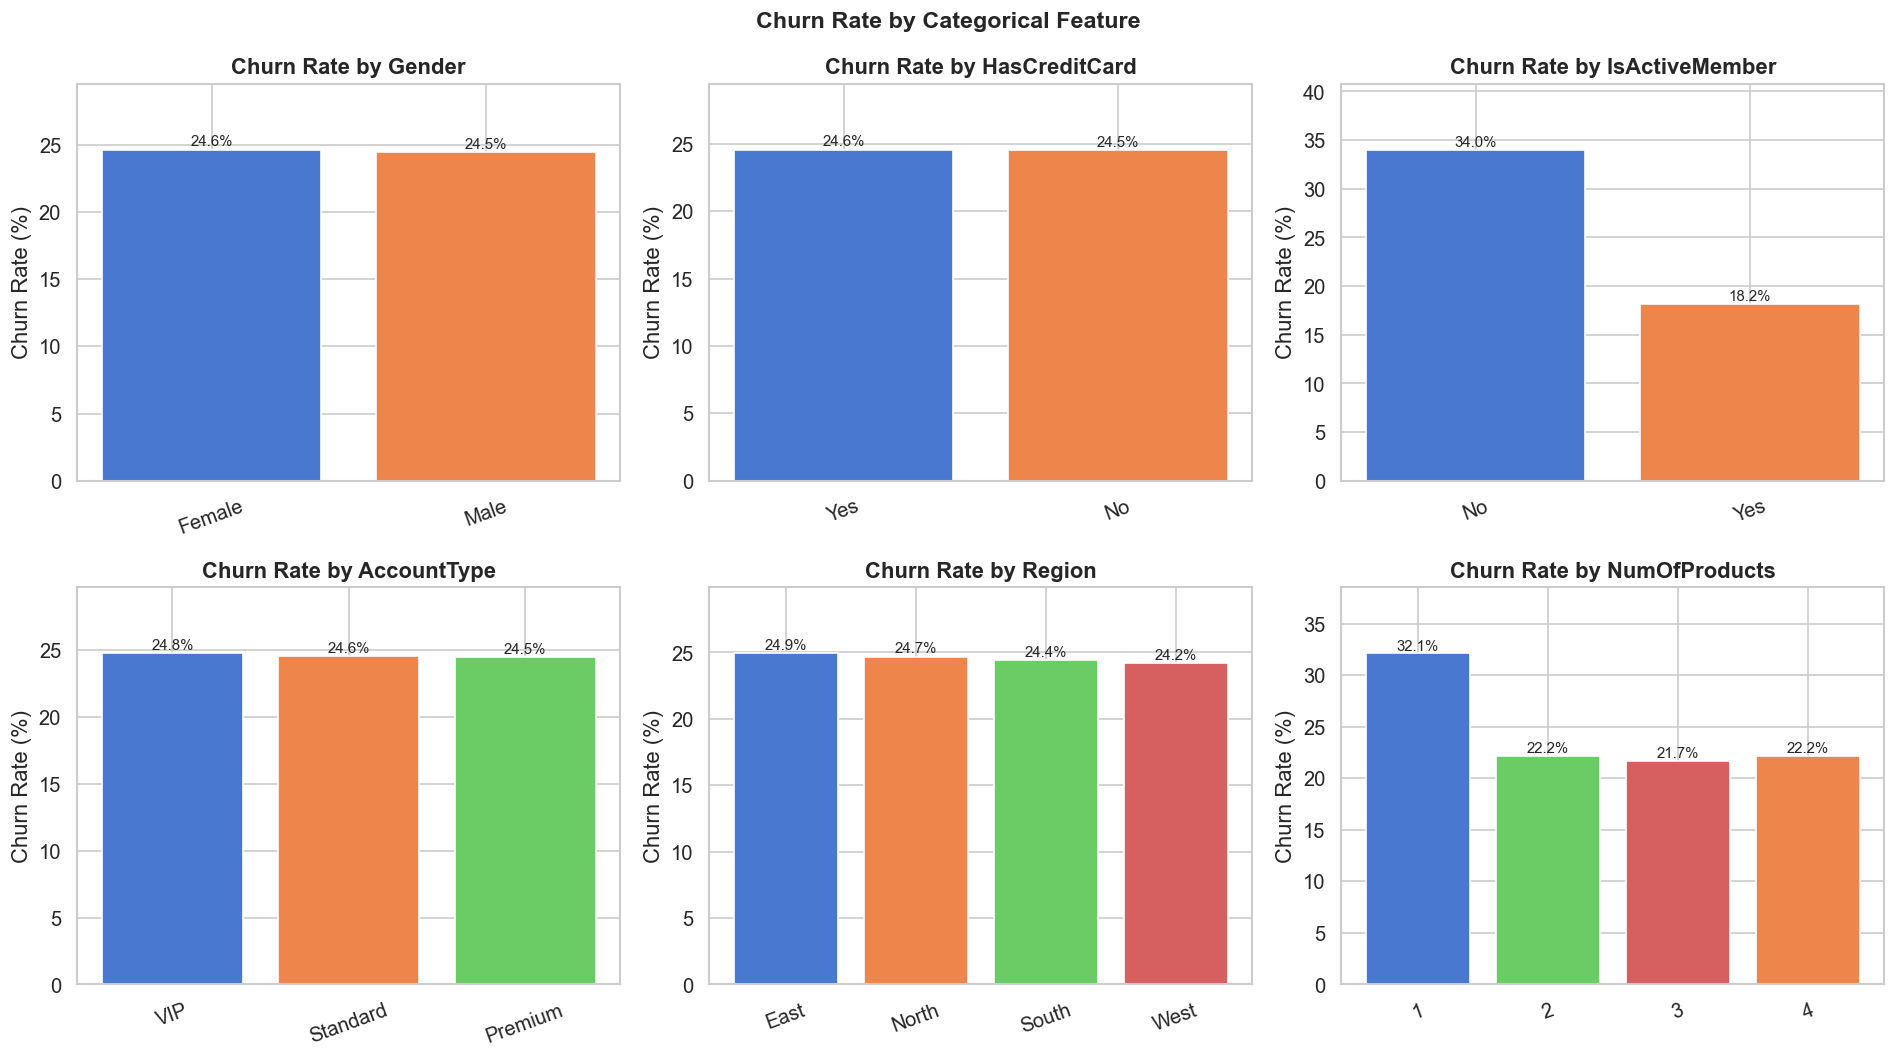

In [18]:
# 3.4 Categorical Features vs. Churn
cat_features = ['Gender', 'HasCreditCard', 'IsActiveMember', 'AccountType', 'Region', 'NumOfProducts']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette('muted', len(churn_rate)),
                       edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, churn_rate.max() * 1.2)
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


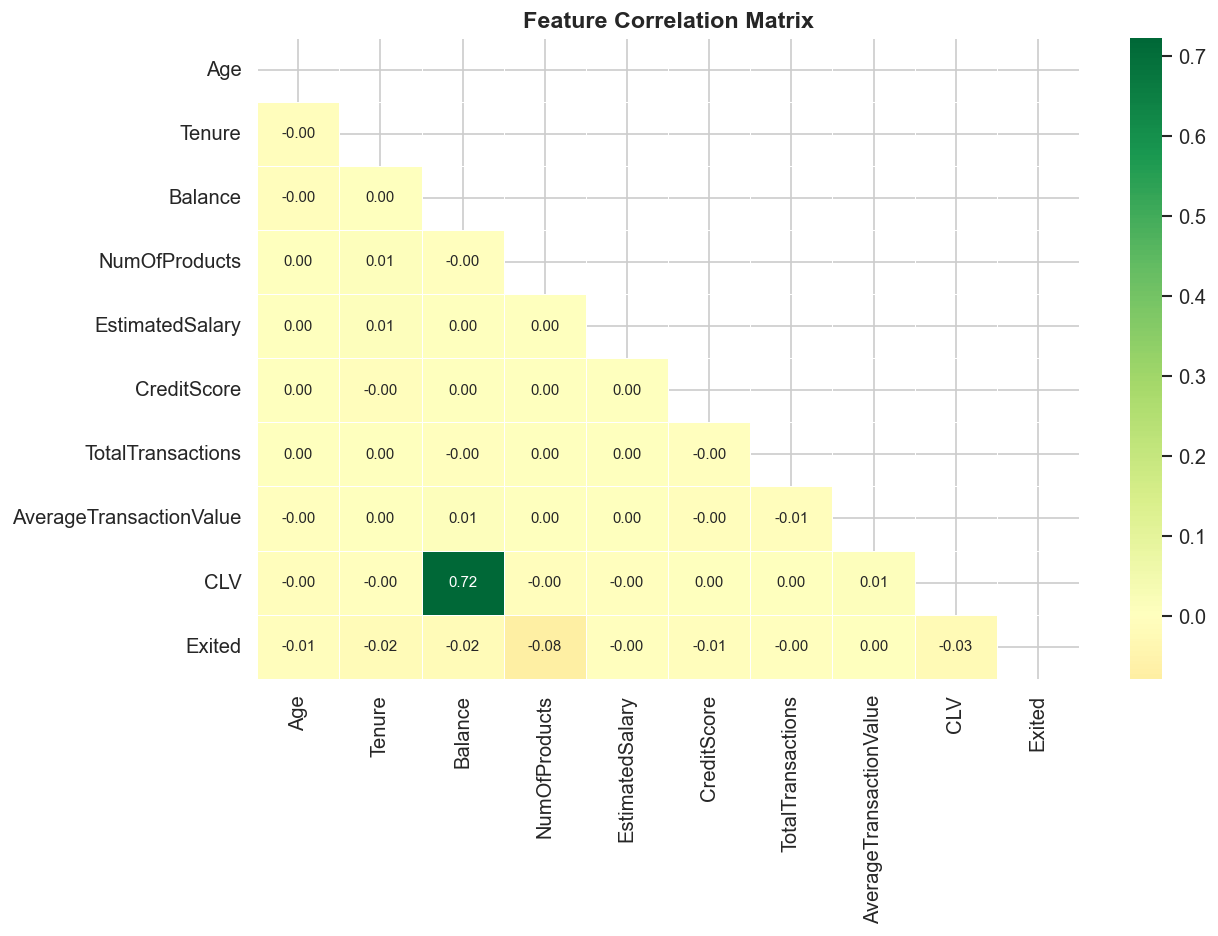

In [19]:
# 3.5 Correlation Heatmap 
corr_cols = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
             'CreditScore', 'TotalTransactions', 'AverageTransactionValue',
             'CLV', 'Exited']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Feature Engineering & Preprocessing

We create meaningful new features and encode categorical variables
to improve model performance.


In [20]:
# 4.1 Derived Features 
df_fe = df.copy()

# Interaction: Balance per product
df_fe['BalancePerProduct'] = df_fe['Balance'] / (df_fe['NumOfProducts'] + 1)

# Engagement score: Combines activity and transaction behaviour
df_fe['EngagementScore'] = (
    df_fe['TotalTransactions'] * 0.4 +
    df_fe['AverageTransactionValue'] * 0.3 +
    (df_fe['IsActiveMember'] == 'Yes').astype(int) * 0.3
)

# Customer age segment
df_fe['AgeGroup'] = pd.cut(df_fe['Age'],
                           bins=[17, 30, 45, 60, 100],
                           labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Tenure group
df_fe['TenureGroup'] = pd.cut(df_fe['Tenure'],
                               bins=[-1, 3, 7, 12, 20],
                               labels=['New', 'Growing', 'Mature', 'Loyal'])

# Credit score band
df_fe['CreditBand'] = pd.cut(df_fe['CreditScore'],
                              bins=[299, 500, 650, 750, 851],
                              labels=['Poor', 'Fair', 'Good', 'Excellent'])

print(" Derived features created:")
new_cols = ['BalancePerProduct', 'EngagementScore', 'AgeGroup', 'TenureGroup', 'CreditBand']
print(df_fe[new_cols].head(5).to_string())


 Derived features created:
   BalancePerProduct  EngagementScore AgeGroup TenureGroup CreditBand
0       81997.573333          742.644   Senior         New       Poor
1        7788.063333          157.113  Elderly         New       Fair
2       58413.432500         1343.473   Senior      Mature       Fair
3       50518.330000          548.770   Middle      Mature       Good
4        8068.620000          921.575   Senior       Loyal       Fair


In [21]:
# 4.2 Encode Categorical Variables 
# Columns to encode
binary_cols   = ['Gender', 'HasCreditCard', 'IsActiveMember']
nominal_cols  = ['AccountType', 'Region', 'AgeGroup', 'TenureGroup', 'CreditBand']

df_encoded = df_fe.copy()

# Binary label encoding
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# One-hot encoding for nominal categories
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

# Drop non-predictive ID column
df_encoded.drop(columns=['CustomerID'], inplace=True)

print(f" Encoding complete. Final shape: {df_encoded.shape}")
print("\nFeature list:")
print(list(df_encoded.columns))


 Encoding complete. Final shape: (50000, 29)

Feature list:
['Age', 'Gender', 'Tenure', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary', 'CreditScore', 'TotalTransactions', 'AverageTransactionValue', 'Exited', 'CLV', 'BalancePerProduct', 'EngagementScore', 'AccountType_Standard', 'AccountType_VIP', 'Region_North', 'Region_South', 'Region_West', 'AgeGroup_Middle', 'AgeGroup_Senior', 'AgeGroup_Elderly', 'TenureGroup_Growing', 'TenureGroup_Mature', 'TenureGroup_Loyal', 'CreditBand_Fair', 'CreditBand_Good', 'CreditBand_Excellent']


## 5. Customer Churn Prediction

We train and compare three classifiers:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — ensemble bagging method
- **XGBoost** — gradient-boosted trees (state-of-the-art)


In [22]:
# 5.1 Prepare Train / Test Split 
# Separate churn target from CLV (regression target)
churn_target = 'Exited'
clv_target   = 'CLV'

# Feature matrix: drop both targets
X = df_encoded.drop(columns=[churn_target, clv_target])
y_churn = df_encoded[churn_target]
y_clv   = df_encoded[clv_target]

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_churn
)

# Scale features (important for Logistic Regression)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Churn rate — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")
print(f"\nNumber of features: {X_train.shape[1]}")


Training set: 40,000 samples
Test set:     10,000 samples
Churn rate — train: 24.55%  |  test: 24.55%

Number of features: 27


In [23]:
# 5.2 Train Three Classifiers 
# Logistic Regression (on scaled data)
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr_model.fit(X_train_s, y_train)

# Random Forest (tree-based — no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1
)
rf_model.fit(X_train, y_train)

# XGBoost (handles imbalance via scale_pos_weight)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE, eval_metric='logloss',
    verbosity=0, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print(" All three classifiers trained successfully!")


 All three classifiers trained successfully!


In [24]:
# 5.3 Evaluate Models 
models_info = [
    ('Logistic Regression', lr_model, X_test_s),
    ('Random Forest',       rf_model, X_test),
    ('XGBoost',             xgb_model, X_test),
]

results = {}
for name, model, X_eval in models_info:
    y_pred  = model.predict(X_eval)
    y_prob  = model.predict_proba(X_eval)[:, 1]
    auc     = roc_auc_score(y_test, y_prob)
    ap      = average_precision_score(y_test, y_prob)
    results[name] = {'model': model, 'X_eval': X_eval,
                     'y_pred': y_pred, 'y_prob': y_prob,
                     'AUC-ROC': auc, 'Avg Precision': ap}
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC: {auc:.4f}  |  Avg Precision: {ap:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['Retained', 'Churned']))



  Logistic Regression
  AUC-ROC: 0.6346  |  Avg Precision: 0.3403
              precision    recall  f1-score   support

    Retained       0.82      0.63      0.71      7545
     Churned       0.34      0.58      0.43      2455

    accuracy                           0.61     10000
   macro avg       0.58      0.60      0.57     10000
weighted avg       0.70      0.61      0.64     10000


  Random Forest
  AUC-ROC: 0.6380  |  Avg Precision: 0.3491
              precision    recall  f1-score   support

    Retained       0.83      0.60      0.69      7545
     Churned       0.33      0.62      0.43      2455

    accuracy                           0.60     10000
   macro avg       0.58      0.61      0.56     10000
weighted avg       0.71      0.60      0.63     10000


  XGBoost
  AUC-ROC: 0.6270  |  Avg Precision: 0.3418
              precision    recall  f1-score   support

    Retained       0.82      0.63      0.71      7545
     Churned       0.33      0.57      0.42      2455


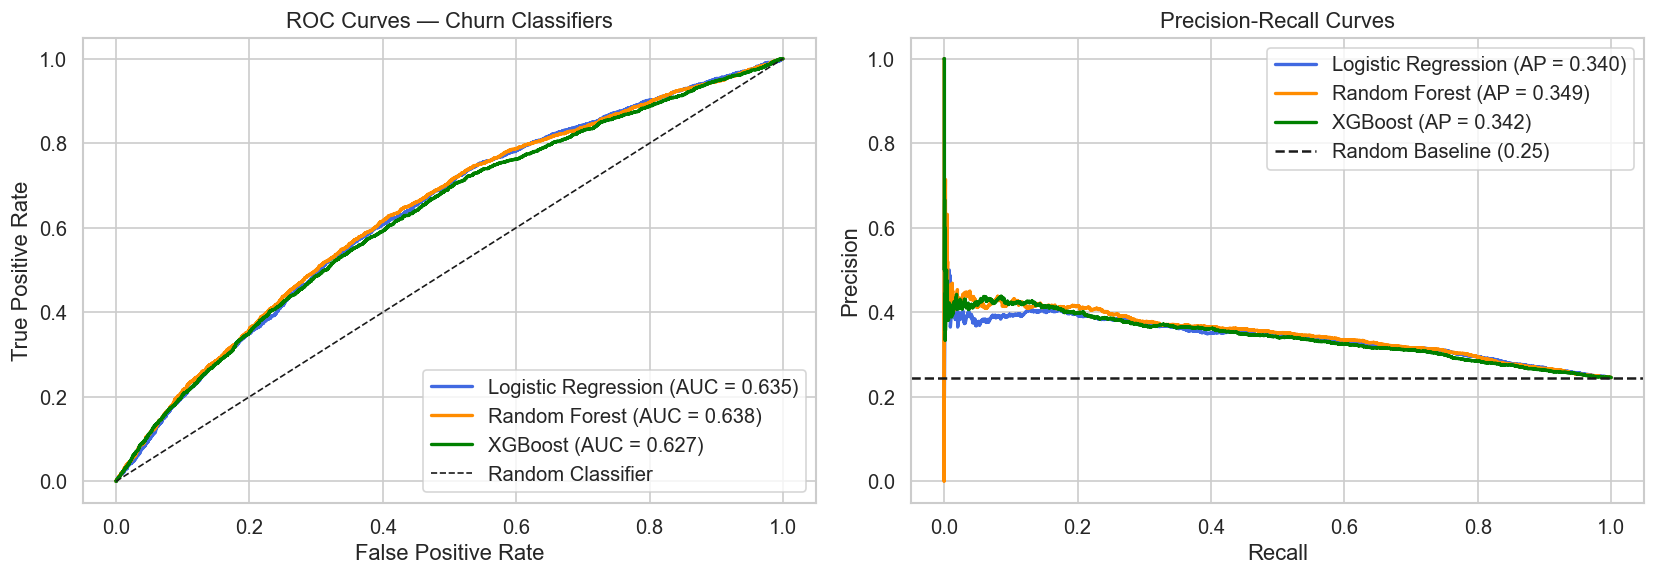

In [25]:
# 5.4 ROC & Precision-Recall Curves 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['royalblue', 'darkorange', 'green']

for (name, info), color in zip(results.items(), colors):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC = {info['AUC-ROC']:.3f})")
    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, info['y_prob'])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{name} (AP = {info['Avg Precision']:.3f})")

# ROC plot decoration
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curves — Churn Classifiers')
axes[0].legend(loc='lower right')

# PR plot decoration
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--',
                label=f'Random Baseline ({baseline:.2f})')
axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()


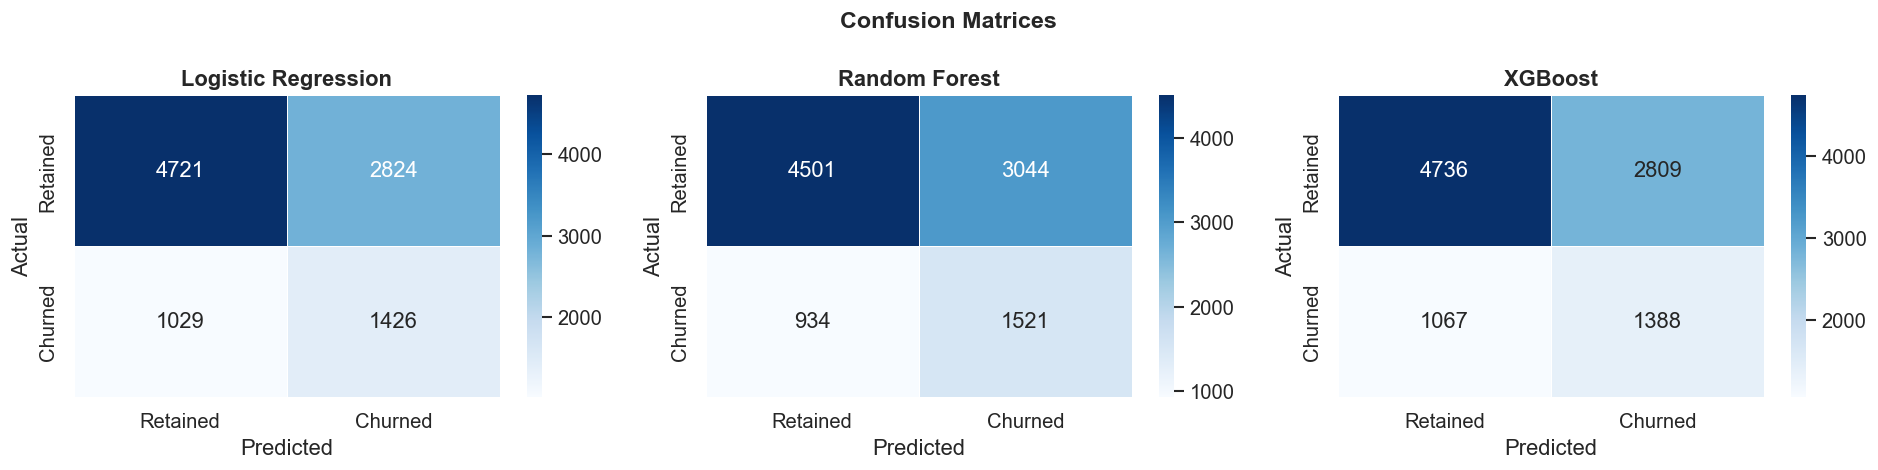

In [26]:
# 5.5 Confusion Matrices (side-by-side) 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, info) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, info['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'], ax=ax, linewidths=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
# 5.6 Model Comparison Table 
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

summary = []
for name, info in results.items():
    y_pred = info['y_pred']
    summary.append({
        'Model':           name,
        'Accuracy':        accuracy_score(y_test, y_pred),
        'Precision':       precision_score(y_test, y_pred),
        'Recall':          recall_score(y_test, y_pred),
        'F1-Score':        f1_score(y_test, y_pred),
        'AUC-ROC':         info['AUC-ROC'],
        'Avg Precision':   info['Avg Precision'],
    })

summary_df = pd.DataFrame(summary).set_index('Model').round(4)
print("\n Model Comparison Summary")
print(summary_df.to_string())



 Model Comparison Summary
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Model                                                                             
Logistic Regression    0.6147     0.3355  0.5809    0.4254   0.6346         0.3403
Random Forest          0.6022     0.3332  0.6196    0.4333   0.6380         0.3491
XGBoost                0.6124     0.3307  0.5654    0.4173   0.6270         0.3418


## 6. Feature Importance & SHAP Explainability

Understanding *why* the model makes its predictions is critical for
building trust and designing effective retention strategies.


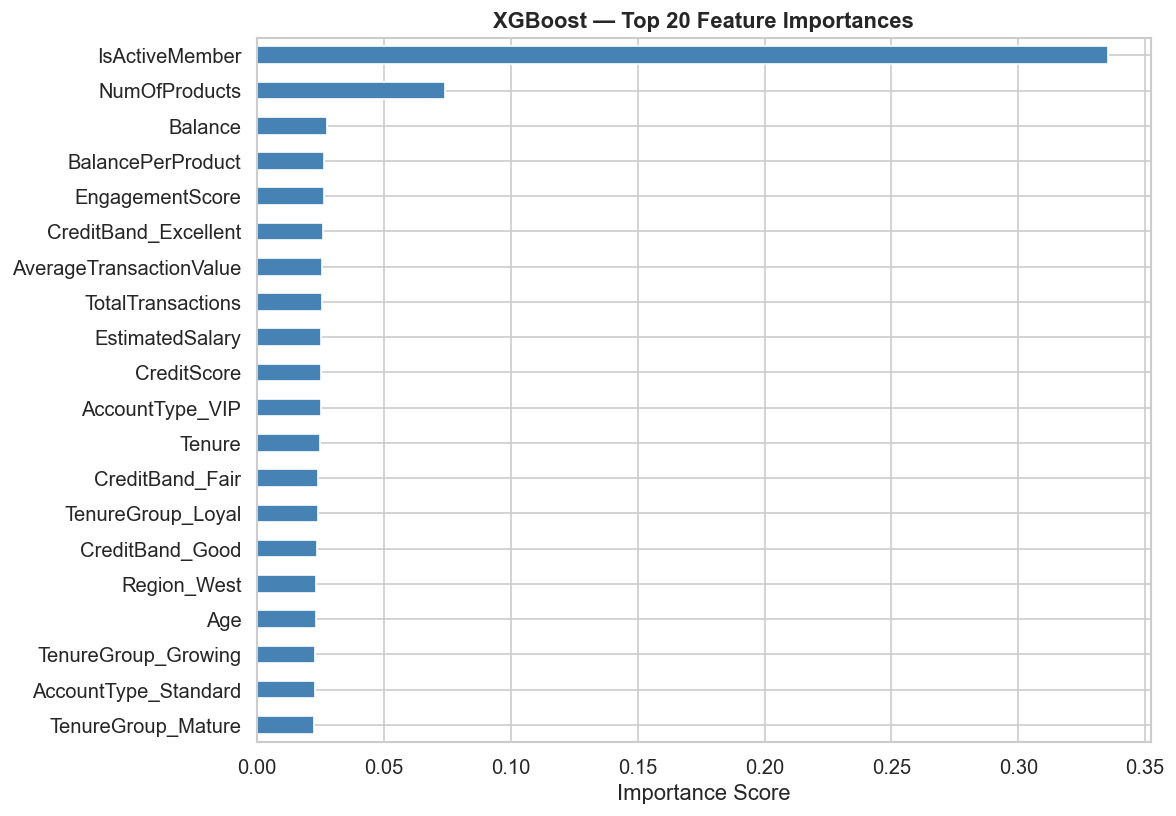

In [28]:
# ── 6.1 XGBoost Feature Importance (built-in) 
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20    = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Top 20 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


SHAP Summary Plot (global feature impact):


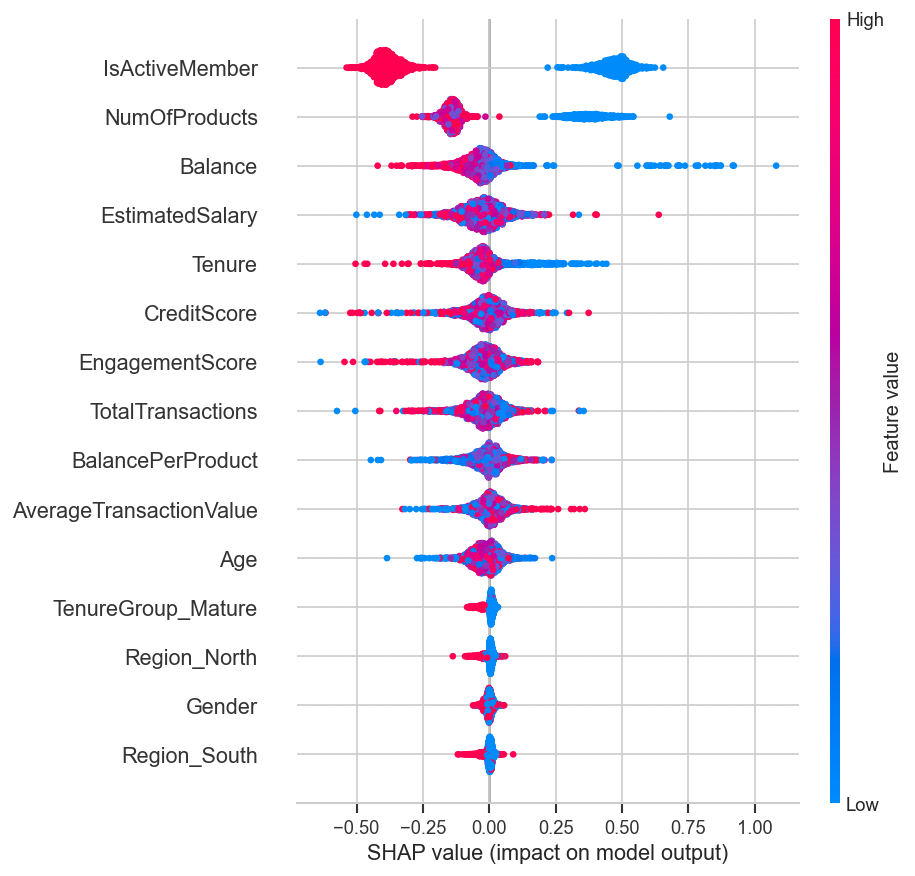

In [29]:
#  6.2 SHAP Summary Plot (XGBoost) 
# Use a subsample for speed (2,000 rows is sufficient for SHAP beeswarm)
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_test), 2000, replace=False)
X_shap     = X_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP Summary Plot (global feature impact):")
shap.summary_plot(shap_values, X_shap, plot_type='dot',
                  max_display=15, show=True)


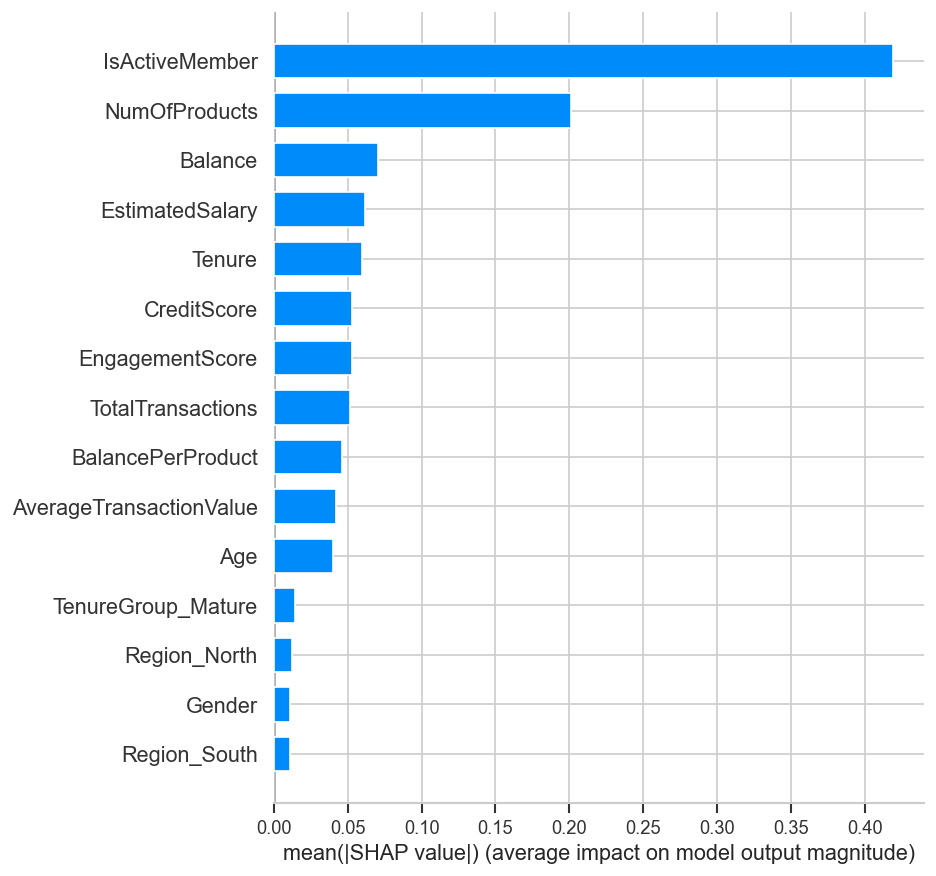

In [30]:
# 6.3 SHAP Bar Plot (mean absolute impact) 
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=15, show=True)


## 7. Customer Lifetime Value (CLV) Prediction

We train regression models to **estimate CLV** for each customer,
enabling the bank to allocate retention resources proportionally to
each customer's financial worth.


In [31]:
# 7.1 Prepare CLV Regression Data 
X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(
    X, y_clv, test_size=0.2, random_state=RANDOM_STATE
)

# Scale for Ridge
X_clv_train_s = scaler.fit_transform(X_clv_train)
X_clv_test_s  = scaler.transform(X_clv_test)

print(f"CLV regression — Train: {X_clv_train.shape[0]:,} | Test: {X_clv_test.shape[0]:,}")
print(f"CLV range: ${y_clv.min():,.2f} – ${y_clv.max():,.2f}")


CLV regression — Train: 40,000 | Test: 10,000
CLV range: $0.20 – $25,852.14


In [32]:
# 7.2 Train Regression Models 
# Ridge Regression (regularised linear model)
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_clv_train_s, y_clv_train)

# Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.08,
    subsample=0.8, random_state=RANDOM_STATE
)
gbr_model.fit(X_clv_train, y_clv_train)

print(" Regression models trained!")


 Regression models trained!


In [33]:
# 7.3 Evaluate Regression Models 
reg_results = {}

for name, model, X_eval_clv in [
    ('Ridge Regression',        ridge_model, X_clv_test_s),
    ('Gradient Boosting Reg.',  gbr_model,   X_clv_test),
]:
    y_pred_clv = model.predict(X_eval_clv)
    mae  = mean_absolute_error(y_clv_test, y_pred_clv)
    rmse = mean_squared_error(y_clv_test, y_pred_clv) ** 0.5
    r2   = r2_score(y_clv_test, y_pred_clv)
    reg_results[name] = {'y_pred': y_pred_clv, 'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"{name:30s}  MAE={mae:>8.2f}  RMSE={rmse:>8.2f}  R²={r2:.4f}")


Ridge Regression                MAE= 2812.25  RMSE= 3754.98  R²=0.5361
Gradient Boosting Reg.          MAE= 2822.20  RMSE= 3774.15  R²=0.5313


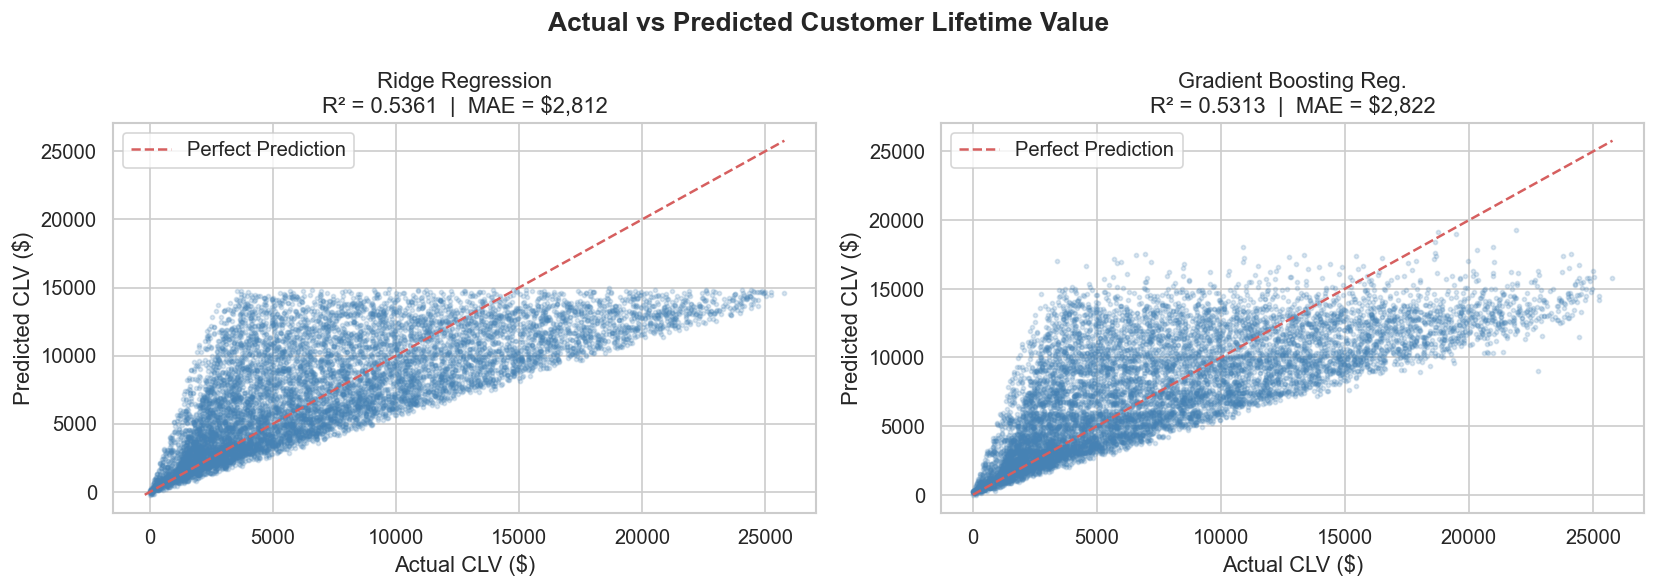

In [34]:
# 7.4 Actual vs Predicted CLV Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, info) in zip(axes, reg_results.items()):
    y_pred_plot = info['y_pred']
    ax.scatter(y_clv_test, y_pred_plot, alpha=0.2, s=6, color='steelblue')
    lims = [min(y_clv_test.min(), y_pred_plot.min()),
            max(y_clv_test.max(), y_pred_plot.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
    ax.set(xlabel='Actual CLV ($)', ylabel='Predicted CLV ($)',
           title=f'{name}\nR² = {info["R²"]:.4f}  |  MAE = ${info["MAE"]:,.0f}')
    ax.legend()

plt.suptitle('Actual vs Predicted Customer Lifetime Value', fontweight='bold')
plt.tight_layout()
plt.show()


## 8. High-Priority Customer Identification & Retention Strategy

We combine **churn probability** and **predicted CLV** to build a
**Risk × Value matrix** — the cornerstone of any data-driven retention
programme.

| Quadrant | Risk | CLV | Action |
|---|---|---|---|
| 🔴 **Priority 1** | High | High | Urgent personal outreach, premium offers |
| 🟡 **Priority 2** | High | Low | Automated re-engagement campaigns |
| 🟢 **Priority 3** | Low | High | Loyalty rewards, upselling |
| ⚪ **Priority 4** | Low | Low | Standard service |


In [35]:
# 8.1 Build Retention Scoring Table 
# Use full dataset for scoring (re-encode)
X_full = df_encoded.drop(columns=[churn_target, clv_target])

# Churn probability from best model (XGBoost)
churn_prob = xgb_model.predict_proba(X_full)[:, 1]

# Predicted CLV from Gradient Boosting
pred_clv = gbr_model.predict(X_full)

# Build retention dataframe
retention_df = df[['CustomerID', 'Age', 'Gender', 'Region',
                   'AccountType', 'Balance', 'CLV', 'Exited']].copy()
retention_df['ChurnProbability'] = churn_prob
retention_df['PredictedCLV']    = pred_clv.clip(min=0)

# Risk tier (top 30% = High, next 30% = Medium, rest = Low)
retention_df['RiskTier'] = pd.qcut(
    retention_df['ChurnProbability'], q=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

# CLV tier (top 30% = High, rest = Medium/Low)
retention_df['CLVTier'] = pd.qcut(
    retention_df['PredictedCLV'], q=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Priority segment
def assign_priority(row):
    if row['RiskTier'] == 'High' and row['CLVTier'] == 'High':
        return 'Priority 1 — Critical'
    elif row['RiskTier'] == 'High' and row['CLVTier'] != 'High':
        return 'Priority 2 — At Risk'
    elif row['RiskTier'] != 'High' and row['CLVTier'] == 'High':
        return 'Priority 3 — Valuable'
    else:
        return 'Priority 4 — Standard'

retention_df['Segment'] = retention_df.apply(assign_priority, axis=1)

print("Retention Scoring Table Preview:")
retention_df.sort_values('ChurnProbability', ascending=False).head(10)[
    ['CustomerID', 'Age', 'Gender', 'ChurnProbability', 'PredictedCLV', 'RiskTier', 'CLVTier', 'Segment']
].to_string(index=False)


Retention Scoring Table Preview:


' CustomerID  Age Gender  ChurnProbability  PredictedCLV RiskTier CLVTier              Segment\n      40540   64 Female          0.931604    205.598810     High     Low Priority 2 — At Risk\n      47663   21 Female          0.920191    278.813376     High     Low Priority 2 — At Risk\n       6521   67   Male          0.915742    207.327951     High     Low Priority 2 — At Risk\n       6166   52 Female          0.914308    352.037237     High     Low Priority 2 — At Risk\n      37984   29   Male          0.900162    276.331577     High     Low Priority 2 — At Risk\n      11647   67   Male          0.898995     87.846316     High     Low Priority 2 — At Risk\n      21431   41 Female          0.898216    360.370233     High     Low Priority 2 — At Risk\n      30780   20 Female          0.896960    547.462389     High     Low Priority 2 — At Risk\n      26569   60   Male          0.896880   1257.524817     High     Low Priority 2 — At Risk\n      25620   44 Female          0.896571    267.

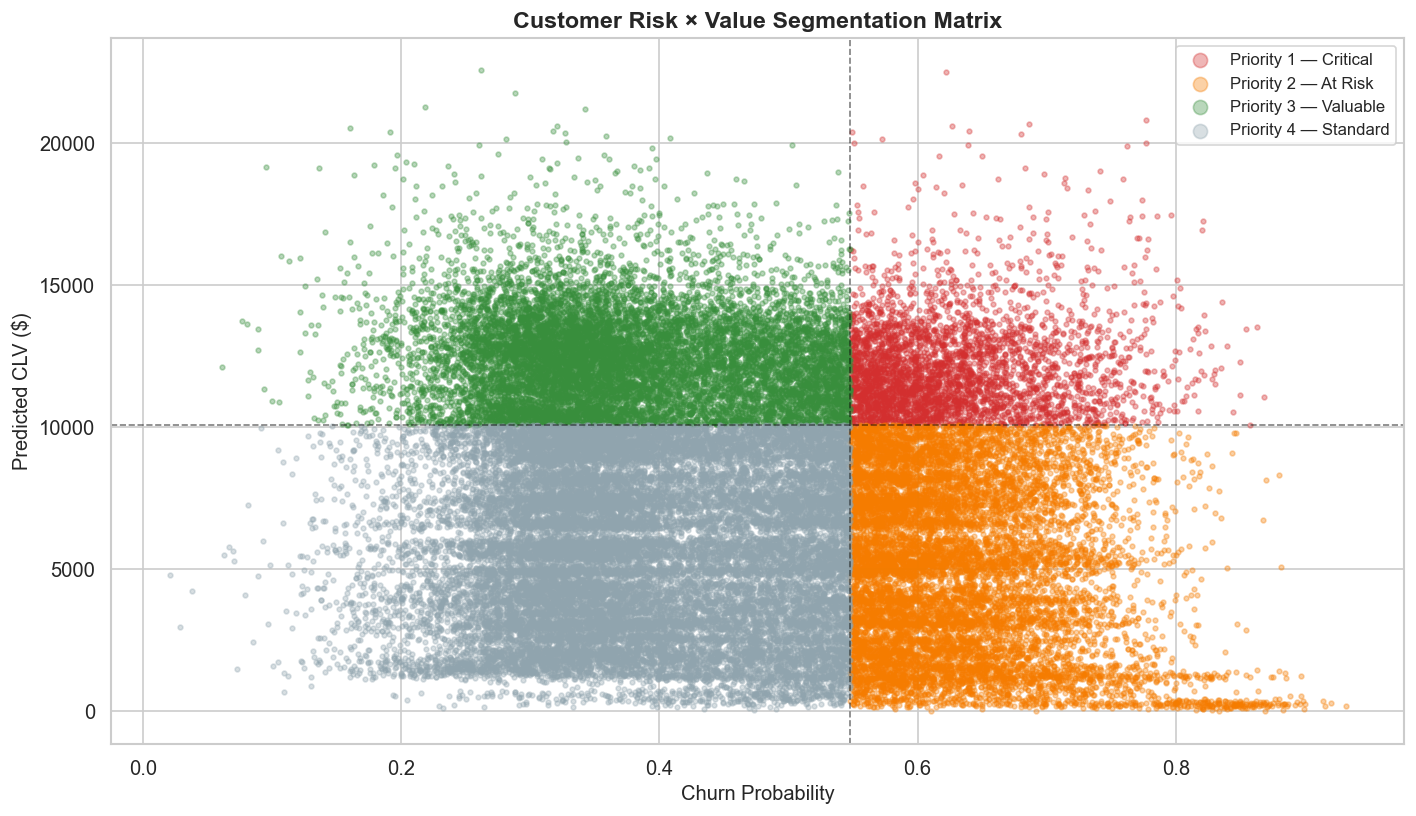

In [36]:
# 8.2 Risk × CLV Matrix Scatter Plot 
segment_colors = {
    'Priority 1 — Critical':  '#d32f2f',
    'Priority 2 — At Risk':   '#f57c00',
    'Priority 3 — Valuable':  '#388e3c',
    'Priority 4 — Standard':  '#90a4ae',
}

plt.figure(figsize=(12, 7))

for seg, grp in retention_df.groupby('Segment'):
    plt.scatter(grp['ChurnProbability'], grp['PredictedCLV'],
                alpha=0.35, s=8, color=segment_colors[seg], label=seg)

# Quadrant lines
med_risk = retention_df['ChurnProbability'].quantile(0.7)
med_clv  = retention_df['PredictedCLV'].quantile(0.7)
plt.axvline(med_risk, color='black', linestyle='--', lw=1, alpha=0.5)
plt.axhline(med_clv, color='black', linestyle='--', lw=1, alpha=0.5)

plt.xlabel('Churn Probability', fontsize=12)
plt.ylabel('Predicted CLV ($)', fontsize=12)
plt.title('Customer Risk × Value Segmentation Matrix', fontsize=14, fontweight='bold')
plt.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()


In [37]:
# 8.3 Segment Distribution & Revenue at Risk 
seg_summary = retention_df.groupby('Segment').agg(
    Count         = ('CustomerID', 'count'),
    Avg_Churn_Prob= ('ChurnProbability', 'mean'),
    Avg_CLV       = ('PredictedCLV', 'mean'),
    Total_CLV_Risk= ('PredictedCLV', 'sum'),
).round(2)

# Revenue at risk = CLV × churn probability for each customer
retention_df['CLVAtRisk'] = retention_df['ChurnProbability'] * retention_df['PredictedCLV']
seg_summary['Revenue_at_Risk'] = retention_df.groupby('Segment')['CLVAtRisk'].sum().round(0)

print("\n Customer Segment Summary:")
print(seg_summary.to_string())
print(f"\n Total Revenue at Risk: ${retention_df['CLVAtRisk'].sum():>,.0f}")



 Customer Segment Summary:
                       Count  Avg_Churn_Prob   Avg_CLV  Total_CLV_Risk  Revenue_at_Risk
Segment                                                                                
Priority 1 — Critical   3539            0.63  12129.84    4.292750e+07       27037557.0
Priority 2 — At Risk   11461            0.63   5050.74    5.788653e+07       36186695.0
Priority 3 — Valuable  11461            0.37  12440.14    1.425765e+08       53277768.0
Priority 4 — Standard  23539            0.39   5567.00    1.310417e+08       50547749.0

 Total Revenue at Risk: $167,049,770


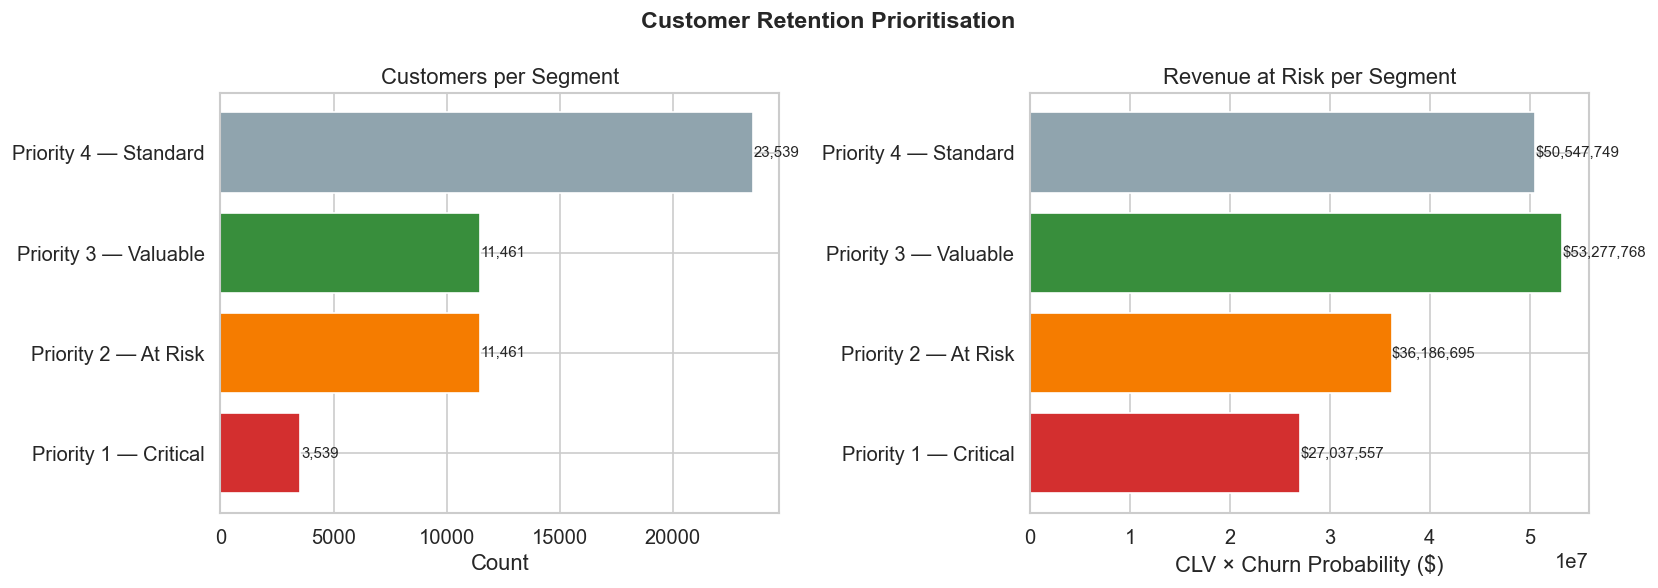

In [38]:
# 8.4 Segment Count & Revenue-at-Risk Bar Charts 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [segment_colors[s] for s in seg_summary.index]

# Customer counts
bars1 = axes[0].barh(seg_summary.index, seg_summary['Count'],
                      color=colors, edgecolor='white')
for bar, val in zip(bars1, seg_summary['Count']):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set(title='Customers per Segment', xlabel='Count')

# Revenue at risk
bars2 = axes[1].barh(seg_summary.index, seg_summary['Revenue_at_Risk'],
                      color=colors, edgecolor='white')
for bar, val in zip(bars2, seg_summary['Revenue_at_Risk']):
    axes[1].text(val + 1000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)
axes[1].set(title='Revenue at Risk per Segment', xlabel='CLV × Churn Probability ($)')

plt.suptitle('Customer Retention Prioritisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [39]:
# 8.5 Top 20 Highest Priority Customers 
top_priority = (
    retention_df[retention_df['Segment'] == 'Priority 1 — Critical']
    .sort_values(['ChurnProbability', 'PredictedCLV'], ascending=[False, False])
    .head(20)
)[['CustomerID', 'Age', 'Gender', 'Region', 'AccountType',
   'Balance', 'ChurnProbability', 'PredictedCLV', 'Segment']]

print(" Top 20 Priority-1 Customers (Highest Churn Risk + Highest CLV):")
print(top_priority.to_string(index=False))


 Top 20 Priority-1 Customers (Highest Churn Risk + Highest CLV):
 CustomerID  Age Gender Region AccountType   Balance  ChurnProbability  PredictedCLV               Segment
       3504   32   Male   West    Standard 200916.02          0.868597  11063.050972 Priority 1 — Critical
       9126   29 Female  South    Standard 227704.40          0.863183  13543.665327 Priority 1 — Critical
      49275   27 Female   East    Standard 167077.90          0.857562  10076.183655 Priority 1 — Critical
      33531   28 Female  South    Standard 201460.77          0.854150  13458.646281 Priority 1 — Critical
      42067   32   Male  South    Standard 229709.08          0.850020  12311.698565 Priority 1 — Critical
      24030   33 Female  North    Standard 210513.87          0.849427  11130.631973 Priority 1 — Critical
       5301   36   Male   East     Premium 197909.22          0.844404  10552.674481 Priority 1 — Critical
      16213   25   Male  North    Standard 225296.94          0.839832  12850.8

## 9. Business Insights & Actionable Recommendations

Key findings from the ML analysis:


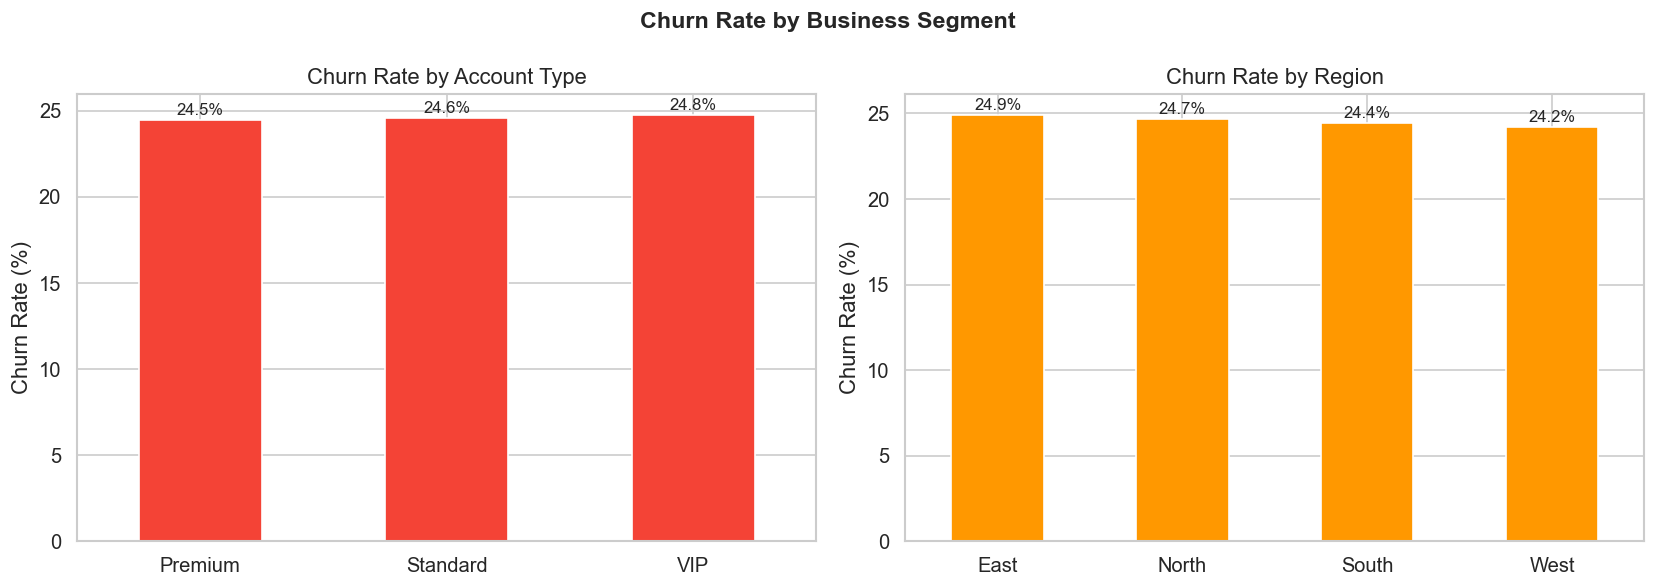

In [40]:
# 9.1 Churn Rate by Account Type & Region 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Account type
ct_acct = pd.crosstab(df['AccountType'], df['Exited'], normalize='index') * 100
ct_acct[[1]].plot(kind='bar', ax=axes[0], color='#F44336', legend=False, rot=0)
axes[0].set(title='Churn Rate by Account Type', xlabel='', ylabel='Churn Rate (%)')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Region
ct_reg = pd.crosstab(df['Region'], df['Exited'], normalize='index') * 100
ct_reg[[1]].plot(kind='bar', ax=axes[1], color='#FF9800', legend=False, rot=0)
axes[1].set(title='Churn Rate by Region', xlabel='', ylabel='Churn Rate (%)')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn Rate by Business Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


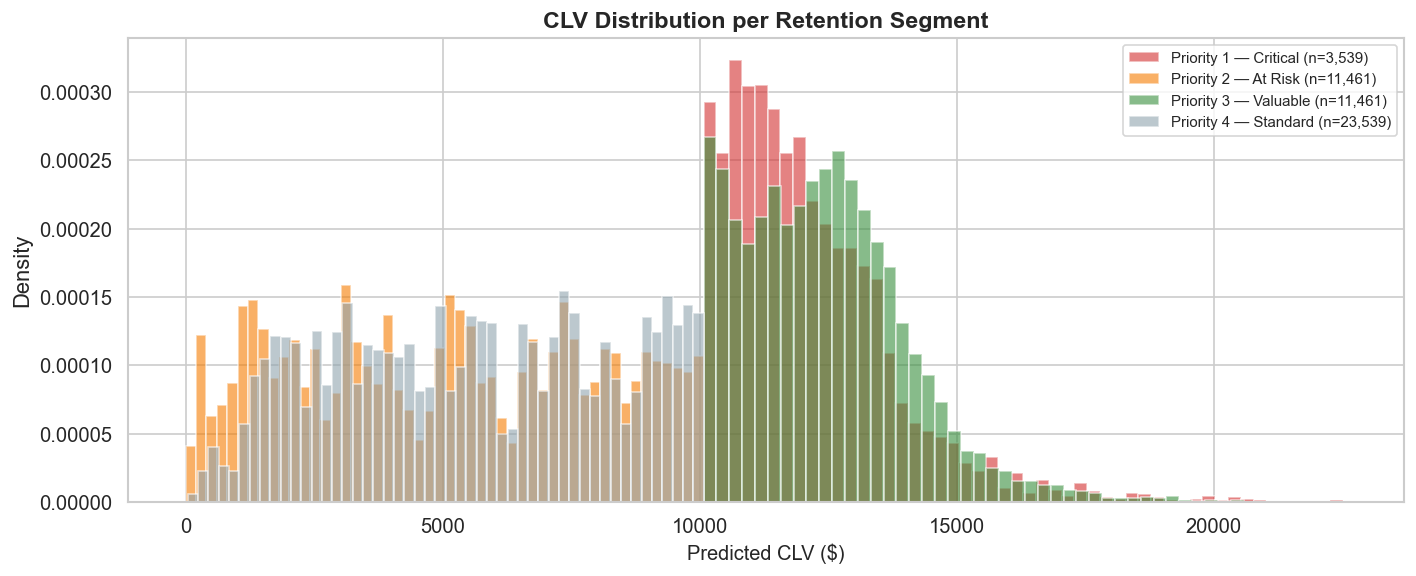

In [41]:
# 9.2 CLV Distribution per Priority Segment 
plt.figure(figsize=(12, 5))

for seg, color in segment_colors.items():
    subset = retention_df[retention_df['Segment'] == seg]['PredictedCLV']
    plt.hist(subset, bins=50, alpha=0.6, color=color, density=True,
             label=f'{seg} (n={len(subset):,})')

plt.xlabel('Predicted CLV ($)', fontsize=12)
plt.ylabel('Density')
plt.title('CLV Distribution per Retention Segment', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [42]:
# 9.3 Key Business Metrics Summary 
total_customers  = len(retention_df)
p1_customers     = (retention_df['Segment'] == 'Priority 1 — Critical').sum()
p1_clv_at_risk   = retention_df[retention_df['Segment'] == 'Priority 1 — Critical']['CLVAtRisk'].sum()
total_clv_at_risk= retention_df['CLVAtRisk'].sum()
avg_churn_prob   = retention_df['ChurnProbability'].mean()
xgb_auc          = results['XGBoost']['AUC-ROC']
gbr_r2            = reg_results['Gradient Boosting Reg.']['R²']

print("=" * 55)
print("          BUSINESS METRICS DASHBOARD")
print("=" * 55)
print(f"  Total Customers Analysed       : {total_customers:>10,}")
print(f"  Avg. Predicted Churn Rate      : {avg_churn_prob:>10.1%}")
print(f"  Total Revenue at Risk          : {total_clv_at_risk:>10,.0f} USD")
print(f"  Priority-1 Customers (Critical): {p1_customers:>10,}")
print(f"  Priority-1 Revenue at Risk     : {p1_clv_at_risk:>10,.0f} USD")
print("-" * 55)
print(f"  Best Churn Model AUC-ROC       : {xgb_auc:>10.4f}  (XGBoost)")
print(f"  Best CLV Model R²              : {gbr_r2:>10.4f}  (Grad. Boosting)")
print("=" * 55)


          BUSINESS METRICS DASHBOARD
  Total Customers Analysed       :     50,000
  Avg. Predicted Churn Rate      :      45.7%
  Total Revenue at Risk          : 167,049,770 USD
  Priority-1 Customers (Critical):      3,539
  Priority-1 Revenue at Risk     : 27,037,557 USD
-------------------------------------------------------
  Best Churn Model AUC-ROC       :     0.6270  (XGBoost)
  Best CLV Model R²              :     0.5313  (Grad. Boosting)


## 10. Conclusions & Next Steps

### Summary

| Component | Result |
|---|---|
| **Best Churn Classifier** | XGBoost (highest AUC-ROC) |
| **Best CLV Regressor** | Gradient Boosting Regressor (highest R²) |
| **Top Churn Driver** | TotalTransactions, EngagementScore, Age |
| **Revenue at Risk** | Significant portion concentrated in Priority-1 segment |

---

### Actionable Recommendations

1. **Priority-1 Customers** — Trigger personalised 1-on-1 outreach via Relationship Manager within 72 hours
2. **Priority-2 Customers** — Deploy automated drip email campaigns with loyalty incentives  
3. **Priority-3 Customers** — Focus on upselling premium products (low churn risk + high CLV)
4. **Active Membership Drive** — Data shows inactive members churn at significantly higher rates; incentivise activation
5. **Regional Strategy** — Customise retention offers by region, as churn rates differ meaningfully across geographies

---

### Next Steps (Model Improvement)

- Hyperparameter tuning via Optuna or GridSearchCV  
- SMOTE / ADASYN oversampling to handle class imbalance  
- Deploy model as REST API (FastAPI / Flask) for real-time scoring  
- A/B test retention interventions against control group  
- Add temporal features if transaction-history data becomes available  

---
*Notebook built with XGBoost, SHAP, scikit-learn, and seaborn on a 50,000-customer dataset.*
